# Estatistica Descritiva com Python e Dados Reais de Futebol

**Dataset:** football-datasets — 92.671 jogadores do Transfermarkt  
**Ferramentas:** Python 3, Pandas, Matplotlib, Seaborn, NumPy, SciPy  
**Ambiente:** Google Colab

> **Instrucao:** Execute as celulas em sequencia (Shift+Enter ou Runtime > Run all).  
> O bloco de dados tenta carregar dados reais do GitHub e usa dados sinteticos como fallback automatico.

## Configuracao Inicial

> **No Colab:** as bibliotecas ja vem instaladas. Execute a celula abaixo so se aparecer erro de `ModuleNotFoundError`.

In [1]:
# Instalacao das bibliotecas (execute apenas se necessario)
# No Google Colab, pandas, numpy, matplotlib e seaborn ja estao disponiveis
!pip install pandas numpy matplotlib seaborn scipy -q

## Parte 0 — Configuracao do Ambiente

### Bloco 0 — Imports e Configuracoes

In [2]:
# ============================================================
# BLOCO 0 — Imports e configuracoes
# Execute este bloco antes de qualquer outro!
# ============================================================

import pandas as pd          # manipulacao de dados tabulares
import numpy as np           # operacoes matematicas vetoriais
import matplotlib.pyplot as plt  # graficos base
import seaborn as sns        # graficos estatisticos avancados
from scipy import stats      # funcoes estatisticas (KDE, distribuicoes)
import warnings

# Suprimir avisos que nao afetam o resultado da analise
warnings.filterwarnings('ignore')

# Configuracoes visuais globais para todos os graficos da sessao
# figure.figsize define a largura e altura padrao em polegadas
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
# whitegrid adiciona linhas de grade brancas sobre fundo cinza claro
sns.set_theme(style="whitegrid", palette="muted")

# Confirmar que tudo foi importado com sucesso
print("Ambiente configurado com sucesso!")
print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")
print(f"  Seaborn : {sns.__version__}")

Ambiente configurado com sucesso!
  Pandas  : 2.2.2
  NumPy   : 2.0.2
  Seaborn : 0.13.2


## Parte 1 — Carregando os Dados

In [3]:
# ============================================================
# BLOCO 1 — Carregando dados (com fallback automatico)
# Tenta dados reais do GitHub; usa sinteticos se falhar
# ============================================================

BASE_URL = "https://raw.githubusercontent.com/salimt/football-datasets/main/datalake/transfermarkt"

try:
    print("Tentando carregar dados reais do GitHub...")
    df_perfis = pd.read_csv(
        f"{BASE_URL}/player_profiles/player_profiles.csv",
        low_memory=False
    )
    df_perf = pd.read_csv(
        f"{BASE_URL}/player_performances/player_performances.csv",
        low_memory=False
    )
    df_valores = pd.read_csv(
        f"{BASE_URL}/player_market_value/player_market_value.csv",
        low_memory=False
    )
    df_lesoes = pd.read_csv(
        f"{BASE_URL}/player_injuries/player_injuries.csv",
        low_memory=False
    )
    print(f"Perfis carregados: {df_perfis.shape[0]:,} jogadores | {df_perfis.shape[1]} colunas")
    print(f"Performances  : {df_perf.shape[0]:,} registros")
    print(f"Valores       : {df_valores.shape[0]:,} registros")
    print(f"Lesoes        : {df_lesoes.shape[0]:,} registros")
    print("Dados reais carregados com sucesso!")

except Exception as e:
    print(f"Falha ao carregar dados online ({type(e).__name__}). Usando dataset sintetico...")

    np.random.seed(42)
    n = 5000

    posicoes = ['Centre-Forward', 'Right Winger', 'Left Winger',
                'Attacking Midfield', 'Central Midfield', 'Defensive Midfield',
                'Right-Back', 'Left-Back', 'Centre-Back', 'Goalkeeper']

    paises = ['Brazil', 'Germany', 'France', 'Spain', 'Argentina',
              'England', 'Portugal', 'Italy', 'Netherlands', 'Belgium']

    df_perfis = pd.DataFrame({
        'player_id': range(1, n+1),
        'player_name': [f'Jogador {i}' for i in range(1, n+1)],
        'Height': np.random.choice(
            ['1,65 m','1,70 m','1,72 m','1,75 m','1,78 m',
             '1,80 m','1,82 m','1,85 m','1,88 m','1,90 m','1,95 m'],
            n, p=[0.02,0.07,0.08,0.12,0.13,0.14,0.13,0.12,0.10,0.06,0.03]
        ),
        'Citizenship': np.random.choice(paises, n,
            p=[0.18,0.12,0.10,0.10,0.10,0.09,0.08,0.08,0.08,0.07]),
        'Position': np.random.choice(posicoes, n,
            p=[0.12,0.09,0.09,0.09,0.13,0.10,0.09,0.09,0.14,0.06]),
        'Foot': np.random.choice(['right','left','both'], n, p=[0.75,0.21,0.04]),
        'Date of birth': pd.to_datetime(
            np.random.choice(pd.date_range('1985-01-01','2005-12-31'), n)
        )
    })

    df_valores = pd.DataFrame({
        'player_id': np.random.randint(1, n+1, 15000),
        'value': np.random.lognormal(mean=11, sigma=2, size=15000).astype(int) * 1000,
        'date_unix': pd.date_range('2015-01-01','2025-01-01', periods=15000)
    })

    df_perf = pd.DataFrame({
        'player_id': np.random.randint(1, n+1, 20000),
        'season': np.random.choice(['20/21','21/22','22/23','23/24','24/25'], 20000),
        'goals': np.random.poisson(3, 20000),
        'assists': np.random.poisson(2, 20000),
        'minutes_played': np.random.choice(["900'","1800'","2700'","3060'"], 20000),
        'yellow_cards': np.random.poisson(2, 20000),
        'direct_red_cards': np.random.poisson(0.1, 20000),
    })

    df_lesoes = pd.DataFrame({
        'player_id': np.random.randint(1, n+1, 5000),
        'season': np.random.choice(['20/21','21/22','22/23','23/24'], 5000),
        'injury_reason': np.random.choice(
            ['Hamstring injury','Knee injury','Thigh problems',
             'Muscle injury','Ankle injury','Back problems'], 5000),
        'days_missed': np.random.choice(
            ['7 days','14 days','21 days','30 days','45 days','60 days'], 5000)
    })

    print("Dataset sintetico criado com sucesso!")
    print(f"  Perfis      : {df_perfis.shape}")
    print(f"  Valores     : {df_valores.shape}")
    print(f"  Performances: {df_perf.shape}")
    print(f"  Lesoes      : {df_lesoes.shape}")

Tentando carregar dados reais do GitHub...
Perfis carregados: 92,671 jogadores | 34 colunas
Performances  : 2 registros
Valores       : 901,429 registros
Lesoes        : 143,195 registros
Dados reais carregados com sucesso!


### Diagnostico — Colunas Carregadas

> Execute esta celula para ver os nomes exatos das colunas dos dados reais.

In [4]:
# ============================================================
# DIAGNOSTICO — Colunas carregadas (execute para verificar)
# ============================================================
print("=== df_perfis ===")
print(f"Shape: {df_perfis.shape}")
print("Colunas:", df_perfis.columns.tolist())
print()
print("=== df_perf ===")
print(f"Shape: {df_perf.shape}")
print("Colunas:", df_perf.columns.tolist())
print()
print("=== df_valores ===")
print(f"Shape: {df_valores.shape}")
print("Colunas:", df_valores.columns.tolist())
print()
print("=== df_lesoes ===")
print(f"Shape: {df_lesoes.shape}")
print("Colunas:", df_lesoes.columns.tolist())

=== df_perfis ===
Shape: (92671, 34)
Colunas: ['player_id', 'player_slug', 'player_name', 'player_image_url', 'name_in_home_country', 'date_of_birth', 'place_of_birth', 'country_of_birth', 'height', 'citizenship', 'is_eu', 'position', 'main_position', 'foot', 'current_club_id', 'current_club_name', 'joined', 'contract_expires', 'outfitter', 'social_media_url', 'player_agent_id', 'player_agent_name', 'contract_option', 'date_of_last_contract_extension', 'on_loan_from_club_id', 'on_loan_from_club_name', 'contract_there_expires', 'second_club_url', 'second_club_name', 'third_club_url', 'third_club_name', 'fourth_club_url', 'fourth_club_name', 'date_of_death']

=== df_perf ===
Shape: (2, 1)
Colunas: ['version https://git-lfs.github.com/spec/v1']

=== df_valores ===
Shape: (901429, 3)
Colunas: ['player_id', 'date_unix', 'value']

=== df_lesoes ===
Shape: (143195, 7)
Colunas: ['player_id', 'season_name', 'injury_reason', 'from_date', 'end_date', 'days_missed', 'games_missed']


### Mapeamento de Colunas

> Adapta automaticamente os nomes de colunas dos dados reais ao formato esperado pelo código. Execute antes do Bloco 3A.

In [5]:
# ============================================================
# MAPEAMENTO DE COLUNAS — adapta dados reais ao formato esperado
# Executa automaticamente, nao precisa editar
# ============================================================

import re

def _normalizar(s):
    """Normaliza nome de coluna: lowercase, sem espacos extras."""
    return re.sub(r'\s+', ' ', str(s)).strip()

# Renomear colunas para o formato esperado pelo restante do codigo
MAPA_PERFIS = {
    # possíveis nomes reais → nome esperado pelo código
    'height': 'Height',
    'Height (m)': 'Height',
    'height_m': 'Height',
    'citizenship': 'Citizenship',
    'nationality': 'Citizenship',
    'country': 'Citizenship',
    'position': 'Position',
    'foot': 'Foot',
    'dominant_foot': 'Foot',
    'date_of_birth': 'Date of birth',
    'birth_date': 'Date of birth',
    'dob': 'Date of birth',
    'name': 'player_name',
    'full_name': 'player_name',
}

# Aplicar mapeamento (case-insensitive, busca aproximada)
cols_perfis = {_normalizar(c).lower(): c for c in df_perfis.columns}
renomear = {}
for alias, esperado in MAPA_PERFIS.items():
    alias_norm = _normalizar(alias).lower()
    if alias_norm in cols_perfis and esperado not in df_perfis.columns:
        renomear[cols_perfis[alias_norm]] = esperado

if renomear:
    df_perfis = df_perfis.rename(columns=renomear)
    print(f"Colunas renomeadas em df_perfis: {renomear}")
else:
    print("df_perfis: colunas ja no formato correto")

# Verificar se colunas essenciais existem
essenciais = ['player_name', 'Height', 'Position', 'Citizenship', 'Foot']
faltando = [c for c in essenciais if c not in df_perfis.columns]
if faltando:
    print(f"ATENCAO: colunas ainda nao encontradas: {faltando}")
    print("Colunas disponíveis:", df_perfis.columns.tolist())
else:
    print("Todas as colunas essenciais presentes:", essenciais)

Colunas renomeadas em df_perfis: {'height': 'Height', 'citizenship': 'Citizenship', 'position': 'Position', 'foot': 'Foot', 'date_of_birth': 'Date of birth'}
Todas as colunas essenciais presentes: ['player_name', 'Height', 'Position', 'Citizenship', 'Foot']


## Parte 2 — Exploracao Inicial dos Dados

### Bloco 2A — Primeiras Linhas do DataFrame

In [6]:
# ============================================================
# BLOCO 2A — Primeiras linhas e estrutura
# ============================================================

# .head() mostra as primeiras 5 linhas por padrao
# Isso nos da uma visao rapida dos nomes das colunas e do formato dos dados
print("=" * 60)
print("PRIMEIRAS 5 LINHAS DO DATASET DE PERFIS")
print("=" * 60)
df_perfis.head()

PRIMEIRAS 5 LINHAS DO DATASET DE PERFIS


,player_id,player_slug,player_name,player_image_url,name_in_home_country,Date of birth,place_of_birth,country_of_birth,Height,Citizenship,...,on_loan_from_club_id,on_loan_from_club_name,contract_there_expires,second_club_url,second_club_name,third_club_url,third_club_name,fourth_club_url,fourth_club_name,date_of_death
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Bloco 2B — Dimensoes e Tipos de Dados

In [7]:
# ============================================================
# BLOCO 2B — Dimensoes e tipos de dados
# ============================================================

# .shape retorna (linhas, colunas) como uma tupla
print(f"Dimensoes: {df_perfis.shape[0]:,} linhas x {df_perfis.shape[1]} colunas\n")

# .dtypes.value_counts() agrupa e conta quantas colunas sao de cada tipo
print("Contagem por tipo de dado:")
print(df_perfis.dtypes.value_counts())

print("\nInformacoes detalhadas por coluna:")
# show_counts=True exibe o numero de valores nao nulos em cada coluna
df_perfis.info(show_counts=True)

Dimensoes: 92,671 linhas x 34 colunas

Contagem por tipo de dado:
object     28
float64     3
int64       2
bool        1
Name: count, dtype: int64

Informacoes detalhadas por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92671 entries, 0 to 92670
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   player_id                        92671 non-null  int64  
 1   player_slug                      92671 non-null  object 
 2   player_name                      92151 non-null  object 
 3   player_image_url                 92671 non-null  object 
 4   name_in_home_country             49653 non-null  object 
 5   Date of birth                    91665 non-null  object 
 6   place_of_birth                   76038 non-null  object 
 7   country_of_birth                 76026 non-null  object 
 8   Height                           92667 non-null  float64
 9   Citizenship         

### Bloco 2C — Valores Faltantes

In [8]:
# ============================================================
# BLOCO 2C — Verificando dados faltantes
# ============================================================

# .isnull() cria um DataFrame de True/False (True = dado faltante)
# .sum() soma os True (que valem 1) por coluna
faltantes = df_perfis.isnull().sum()

# Calcular o percentual de dados faltantes em relacao ao total de linhas
perc_faltantes = (faltantes / len(df_perfis) * 100).round(2)

# Montar um DataFrame de resumo com apenas as colunas que tem algum faltante
# .query() filtra linhas com base em uma condicao escrita como string
resumo_nulos = pd.DataFrame({
    'Valores Faltantes': faltantes,
    'Percentual (%)': perc_faltantes
}).query('`Valores Faltantes` > 0').sort_values('Percentual (%)', ascending=False)

print("Colunas com dados faltantes:")
print(resumo_nulos.to_string())

Colunas com dados faltantes:
                                 Valores Faltantes  Percentual (%)
fourth_club_name                             92670          100.00
fourth_club_url                              92670          100.00
third_club_url                               92629           99.95
third_club_name                              92629           99.95
date_of_death                                92399           99.71
second_club_url                              91693           98.94
second_club_name                             91693           98.94
contract_there_expires                       90165           97.30
contract_option                              89100           96.15
on_loan_from_club_id                         88913           95.94
on_loan_from_club_name                       88913           95.94
outfitter                                    86713           93.57
date_of_last_contract_extension              84308           90.98
social_media_url                 

### Bloco 2D — Heatmap de Dados Faltantes

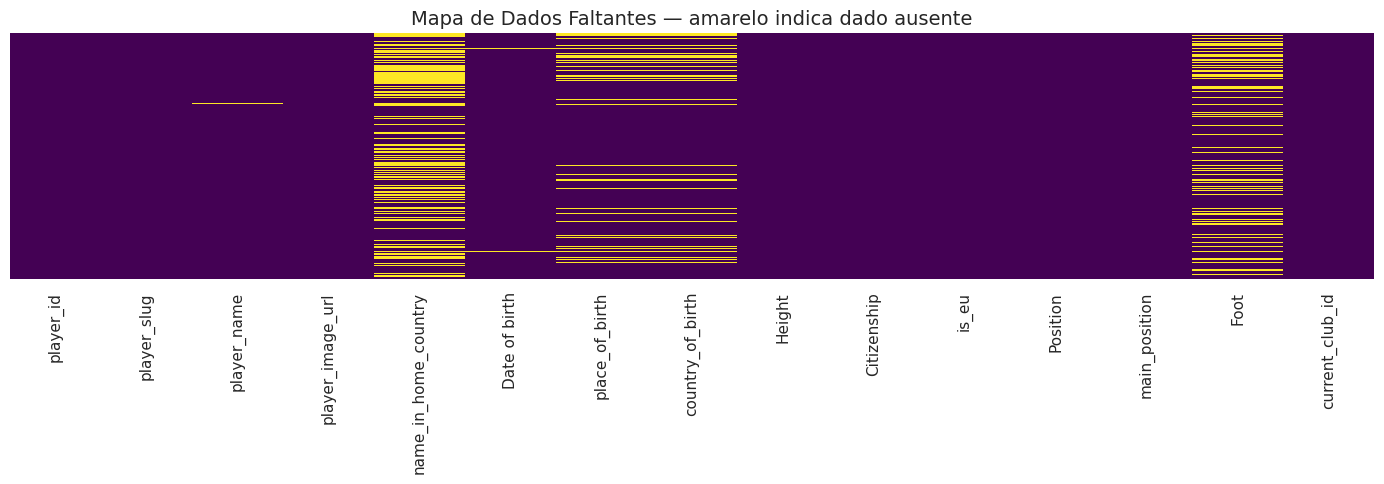

Dados faltantes (NaN) sao comuns em datasets reais.
Decisoes possiveis: remover linhas, preencher com media/moda, ou ignorar a coluna.


In [9]:
# ============================================================
# BLOCO 2D — Heatmap de dados faltantes
# ============================================================

# Selecionar apenas as 15 primeiras colunas para o grafico nao ficar poluido
colunas_amostra = df_perfis.columns[:15]

plt.figure(figsize=(14, 5))

# df.isnull() retorna True onde o dado esta faltando
# sns.heatmap plotara True como cor clara e False como cor escura
sns.heatmap(
    df_perfis[colunas_amostra].isnull(),
    yticklabels=False,  # ocultar indices das linhas (sao 90 mil — poluiria o grafico)
    cbar=False,         # sem barra de cor — so precisamos do padrao visual
    cmap='viridis'      # escala de cores: roxo (dados presentes) → amarelo (faltante)
)
plt.title('Mapa de Dados Faltantes — amarelo indica dado ausente', fontsize=14)
plt.tight_layout()
plt.show()

print("Dados faltantes (NaN) sao comuns em datasets reais.")
print("Decisoes possiveis: remover linhas, preencher com media/moda, ou ignorar a coluna.")

## Parte 3 — Medidas de Tendencia Central

### Bloco 3A — Limpando a Coluna de Altura

In [10]:
# ============================================================
# BLOCO 3A — Limpando e convertendo a coluna de altura
# ============================================================

df_altura = df_perfis[['player_name', 'Height', 'Position', 'Citizenship']].copy()

# Mostrar amostra dos valores brutos para diagnóstico
amostra_raw = df_perfis['Height'].dropna().head(10).tolist()
print("Valores brutos de Height:", amostra_raw)

# Conversão robusta: suporta "1,84 m", "1.84 m", "184", "184 cm"
s = (
    df_altura['Height']
    .astype(str)
    .str.replace(' m', '', regex=False)
    .str.replace(' cm', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
df_altura['altura_m'] = pd.to_numeric(s, errors='coerce')

# Se os valores estiverem em cm (>10), converter para metros
mask_cm = df_altura['altura_m'] > 10
if mask_cm.sum() > mask_cm.sum() * 0 and mask_cm.any():
    proporcao_cm = mask_cm.sum() / df_altura['altura_m'].notna().sum()
    if proporcao_cm > 0.5:  # mais da metade em cm → converter tudo
        print(f"Formato detectado: cm (convertendo {mask_cm.sum()} valores)")
        df_altura['altura_m'] = df_altura['altura_m'] / 100
    else:
        df_altura.loc[mask_cm, 'altura_m'] = df_altura.loc[mask_cm, 'altura_m'] / 100

df_altura = df_altura[df_altura['altura_m'].between(1.50, 2.10)]

print(f"Alturas validas: {len(df_altura):,} jogadores")
if len(df_altura) > 0:
    print(df_altura.head(10).to_string())
else:
    print("AVISO: Nenhuma altura valida apos conversao.")
    print("Valores unicos de Height:", df_perfis['Height'].dropna().unique()[:15].tolist())

Valores brutos de Height: [0.0, 171.0, 184.0, 183.0, 180.0, 198.0, 186.0, 175.0, 181.0, 182.0]
Formato detectado: cm (convertendo 73799 valores)
Alturas validas: 73,799 jogadores
                     player_name  Height                       Position             Citizenship  altura_m
1         Éverton Silva (100011)   171.0          Defender - Right-Back                  Brazil      1.71
2            Miroslav Klose (10)   184.0        Attack - Centre-Forward                 Germany      1.84
3          John Thompson (10001)   183.0          Defender - Right-Back                 Ireland      1.83
4         Carlos Auzqui (100001)   180.0          Attack - Right Winger               Argentina      1.80
5       Sodick Adejumo (1000152)   198.0  Midfield - Defensive Midfield         France  Nigeria      1.98
6       Matheo Sánchez (1000153)   186.0           Attack - Left Winger                  France      1.86
7             Brian Cash (10002)   175.0      Midfield - Right Midfield        

### Bloco 3B — Media, Mediana e Moda

In [11]:
# ============================================================
# BLOCO 3B — Calculando Media, Mediana e Moda
# ============================================================

# Isolar a coluna de altura como uma Series para facilitar os calculos
altura = df_altura['altura_m']

# Calculos de tendencia central
media    = altura.mean()     # soma de todos os valores / quantidade
mediana  = altura.median()   # valor do meio apos ordenacao crescente
moda     = altura.mode()[0]  # valor que aparece mais vezes (mode() retorna Series)
minimo   = altura.min()
maximo   = altura.max()

print("=" * 50)
print("  MEDIDAS DE TENDENCIA CENTRAL — ALTURA (m)")
print("=" * 50)
print(f"  Media    : {media:.3f} m  ({media*100:.1f} cm)")
print(f"  Mediana  : {mediana:.3f} m  ({mediana*100:.1f} cm)")
print(f"  Moda     : {moda:.3f} m  ({moda*100:.1f} cm)")
print(f"  Minimo   : {minimo:.2f} m")
print(f"  Maximo   : {maximo:.2f} m")
print("=" * 50)

print(f"""
Interpretacao:
  A altura media de um jogador profissional e {media*100:.1f} cm.
  Quando media e mediana sao proximas, a distribuicao e simetrica.
  A moda ({moda*100:.1f} cm) e a altura que aparece com mais frequencia.
""")

  MEDIDAS DE TENDENCIA CENTRAL — ALTURA (m)
  Media    : 1.816 m  (181.6 cm)
  Mediana  : 1.820 m  (182.0 cm)
  Moda     : 1.800 m  (180.0 cm)
  Minimo   : 1.52 m
  Maximo   : 2.10 m

Interpretacao:
  A altura media de um jogador profissional e 181.6 cm.
  Quando media e mediana sao proximas, a distribuicao e simetrica.
  A moda (180.0 cm) e a altura que aparece com mais frequencia.



### Bloco 3C — O metodo describe()

In [12]:
# ============================================================
# BLOCO 3C — Resumo automatico com .describe()
# ============================================================

# .describe() retorna um resumo completo de todas as estatisticas basicas
# .round(4) arredonda para 4 casas decimais para facilitar a leitura
print("Resumo estatistico completo com .describe():")
print(df_altura['altura_m'].describe().round(4).to_string())

print("""
O que cada linha significa:
  count  → numero de observacoes validas (sem NaN)
  mean   → media aritmetica
  std    → desvio padrao
  min    → valor minimo
  25%    → primeiro quartil (Q1): 25% dos valores estao abaixo deste numero
  50%    → mediana (Q2): metade dos valores abaixo, metade acima
  75%    → terceiro quartil (Q3): 75% dos valores estao abaixo deste numero
  max    → valor maximo
""")

Resumo estatistico completo com .describe():
count    73799.0000
mean         1.8159
std          0.0669
min          1.5200
25%          1.7700
50%          1.8200
75%          1.8600
max          2.1000

O que cada linha significa:
  count  → numero de observacoes validas (sem NaN)
  mean   → media aritmetica
  std    → desvio padrao
  min    → valor minimo
  25%    → primeiro quartil (Q1): 25% dos valores estao abaixo deste numero
  50%    → mediana (Q2): metade dos valores abaixo, metade acima
  75%    → terceiro quartil (Q3): 75% dos valores estao abaixo deste numero
  max    → valor maximo



## Parte 4 — Medidas de Dispersao

### Bloco 4A — Dispersao da Altura

In [13]:
# ============================================================
# BLOCO 4A — Medidas de dispersao para a altura
# ============================================================

# .var() calcula a variancia: media dos quadrados dos desvios em relacao a media
variancia = altura.var()
# .std() calcula o desvio padrao: raiz quadrada da variancia
# Vantagem: esta na mesma unidade dos dados originais (metros, neste caso)
desvio    = altura.std()
# Amplitude: diferenca entre o maior e o menor valor
amplitude = altura.max() - altura.min()
# Quartis: dividem os dados em quatro partes iguais
q1        = altura.quantile(0.25)   # primeiro quartil: 25% dos dados estao abaixo
q3        = altura.quantile(0.75)   # terceiro quartil: 75% dos dados estao abaixo
# IQR — Intervalo Interquartil: nao e afetado por outliers extremos
iqr       = q3 - q1

print("=" * 50)
print("  MEDIDAS DE DISPERSAO — ALTURA")
print("=" * 50)
print(f"  Variancia        : {variancia:.6f} m^2")
print(f"  Desvio Padrao    : {desvio:.4f} m  ({desvio*100:.2f} cm)")
print(f"  Amplitude        : {amplitude:.2f} m")
print(f"  Q1 (25%)         : {q1:.3f} m")
print(f"  Q3 (75%)         : {q3:.3f} m")
print(f"  IQR (Q3 - Q1)    : {iqr:.4f} m  ({iqr*100:.2f} cm)")
print("=" * 50)

# Regra dos 1.5 x IQR para identificar outliers
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr
# O operador | significa "ou": seleciona linhas abaixo do limite OU acima do limite
outliers = altura[(altura < limite_inf) | (altura > limite_sup)]

print(f"""
Deteccao de Outliers (Regra 1.5 x IQR):
  Limite inferior : {limite_inf:.3f} m
  Limite superior : {limite_sup:.3f} m
  Outliers encontrados: {len(outliers)} jogadores
  ({100*len(outliers)/len(altura):.2f}% do total)
""")

  MEDIDAS DE DISPERSAO — ALTURA
  Variancia        : 0.004475 m^2
  Desvio Padrao    : 0.0669 m  (6.69 cm)
  Amplitude        : 0.58 m
  Q1 (25%)         : 1.770 m
  Q3 (75%)         : 1.860 m
  IQR (Q3 - Q1)    : 0.0900 m  (9.00 cm)

Deteccao de Outliers (Regra 1.5 x IQR):
  Limite inferior : 1.635 m
  Limite superior : 1.995 m
  Outliers encontrados: 342 jogadores
  (0.46% do total)



### Bloco 4B — Dispersao do Valor de Mercado

In [14]:
# ============================================================
# BLOCO 4B — Dispersao do Valor de Mercado
# ============================================================

# Queremos apenas o valor mais recente de cada jogador
# 1. sort_values: ordena por data (mais recente primeiro)
# 2. drop_duplicates: mantém apenas a primeira ocorrencia de cada player_id
#    como ja ordenamos com o mais recente primeiro, "keep='first'" pega o mais recente
df_valor_recente = (
    df_valores
    .sort_values('date_unix', ascending=False)
    .drop_duplicates(subset='player_id', keep='first')
)

# Isolar a coluna de valor como uma Series
valor = df_valor_recente['value']

print("=" * 55)
print("  MEDIDAS — VALOR DE MERCADO (EUR)")
print("=" * 55)
print(f"  Jogadores com valor    : {len(valor):,}")
print(f"  Media                  : EUR {valor.mean():>14,.0f}")
print(f"  Mediana                : EUR {valor.median():>14,.0f}")
print(f"  Desvio Padrao          : EUR {valor.std():>14,.0f}")
print(f"  Minimo                 : EUR {valor.min():>14,.0f}")
print(f"  Maximo                 : EUR {valor.max():>14,.0f}")
print("=" * 55)

print(f"""
Media vs Mediana no Valor de Mercado:
  Media   = EUR {valor.mean():,.0f}
  Mediana = EUR {valor.median():,.0f}

  Quando a media e muito maior que a mediana, a distribuicao
  e assimetrica a direita: poucos jogadores com valores
  altissimos puxam a media para cima.
  Neste caso, a MEDIANA representa melhor o jogador tipico.
""")

  MEDIDAS — VALOR DE MERCADO (EUR)
  Jogadores com valor    : 69,441
  Media                  : EUR        761,319
  Mediana                : EUR              0
  Desvio Padrao          : EUR      4,342,874
  Minimo                 : EUR              0
  Maximo                 : EUR    200,000,000

Media vs Mediana no Valor de Mercado:
  Media   = EUR 761,319
  Mediana = EUR 0

  Quando a media e muito maior que a mediana, a distribuicao
  e assimetrica a direita: poucos jogadores com valores
  altissimos puxam a media para cima.
  Neste caso, a MEDIANA representa melhor o jogador tipico.



## Parte 5 — Distribuicao de Frequencias

### Bloco 5A — Frequencia por Posicao

In [15]:
# ============================================================
# BLOCO 5A — Frequencia por posicao (variavel qualitativa)
# ============================================================

# A coluna Position tem formato: "Attack - Centre-Forward"
# .str.split(' - ') divide em lista: ['Attack', 'Centre-Forward']
# .str[-1] pega o ultimo elemento da lista (a posicao especifica)
# .str.strip() remove espacos residuais
df_perfis['posicao_simples'] = (
    df_perfis['Position']
    .astype(str)
    .str.split(' - ')
    .str[-1]
    .str.strip()
)

# .value_counts() conta as ocorrencias de cada posicao e ordena (maior → menor)
# .head(15) retorna apenas as 15 primeiras (mais frequentes)
freq_posicao = df_perfis['posicao_simples'].value_counts().head(15)

print("TOP 15 POSICOES MAIS COMUNS:")
print("-" * 45)
# Criamos um histograma de texto para visualizar diretamente no terminal
for pos, count in freq_posicao.items():
    # Calculamos o comprimento da barra proporcional ao valor maximo
    barra = '#' * int(count / freq_posicao.max() * 30)
    print(f"  {pos:<25} {count:>6,}  {barra}")

TOP 15 POSICOES MAIS COMUNS:
---------------------------------------------
  Centre-Back               15,074  ##############################
  Centre-Forward            12,070  ########################
  Goalkeeper                10,276  ####################
  Central Midfield           9,546  ##################
  Defensive Midfield         6,999  #############
  Right-Back                 6,502  ############
  Left-Back                  6,116  ############
  Attacking Midfield         5,821  ###########
  Right Winger               4,790  #########
  Left Winger                4,756  #########
  Midfield                   3,148  ######
  Defender                   2,013  ####
  Attack                     1,885  ###
  Right Midfield             1,545  ###
  Left Midfield              1,314  ##


### Bloco 5B — Frequencia por Pais

In [16]:
# ============================================================
# BLOCO 5B — Frequencia por pais (Top 20)
# ============================================================

# value_counts sem argumento retorna contagem absoluta
freq_pais = df_perfis['Citizenship'].value_counts().head(20)

print("TOP 20 PAISES COM MAIS JOGADORES PROFISSIONAIS:")
print("-" * 55)
for pais, count in freq_pais.items():
    barra = '#' * int(count / freq_pais.max() * 25)
    # Calculamos o percentual manualmente dividindo pelo total de linhas
    pct = count / len(df_perfis) * 100
    print(f"  {pais:<22} {count:>6,} ({pct:.1f}%)  {barra}")

TOP 20 PAISES COM MAIS JOGADORES PROFISSIONAIS:
-------------------------------------------------------
  Italy                  12,574 (13.6%)  #########################
  Spain                   5,936 (6.4%)  ###########
  Brazil                  5,484 (5.9%)  ##########
  England                 4,131 (4.5%)  ########
  France                  3,988 (4.3%)  #######
  Türkiye                 3,172 (3.4%)  ######
  Germany                 3,147 (3.4%)  ######
  Portugal                2,210 (2.4%)  ####
  Argentina               1,922 (2.1%)  ###
  Poland                  1,788 (1.9%)  ###
  Mexico                  1,761 (1.9%)  ###
  Belgium                 1,725 (1.9%)  ###
  Netherlands             1,628 (1.8%)  ###
  United States           1,373 (1.5%)  ##
  Hungary                 1,319 (1.4%)  ##
  Ukraine                 1,245 (1.3%)  ##
  Japan                   1,202 (1.3%)  ##
  Denmark                 1,065 (1.1%)  ##
  Russia                    999 (1.1%)  #
  Greece     

### Bloco 5C — Pe Dominante

In [17]:
# ============================================================
# BLOCO 5C — Distribuicao do pe dominante
# ============================================================

# normalize=True retorna proporcoes entre 0 e 1
# Multiplicamos por 100 para exibir como percentual
freq_pe = df_perfis['Foot'].value_counts(normalize=True) * 100

print("DISTRIBUICAO DO PE DOMINANTE:")
print("-" * 35)
for pe, pct in freq_pe.items():
    print(f"  {str(pe):<10} : {pct:.2f}%")

print("""
Curiosidade estatistica:
  Na populacao geral, cerca de 10% das pessoas sao canhotas.
  No futebol profissional, a proporcao de canhotos tende a ser
  mais alta — jogadores canhotos sao relativamente raros e por
  isso mais valorizados taticamente.
""")

DISTRIBUICAO DO PE DOMINANTE:
-----------------------------------
  right      : 71.10%
  left       : 24.38%
  both       : 4.52%

Curiosidade estatistica:
  Na populacao geral, cerca de 10% das pessoas sao canhotas.
  No futebol profissional, a proporcao de canhotos tende a ser
  mais alta — jogadores canhotos sao relativamente raros e por
  isso mais valorizados taticamente.



## Parte 6 — Visualizacoes Estatisticas

### Bloco 6A — Histograma com Curva de Densidade

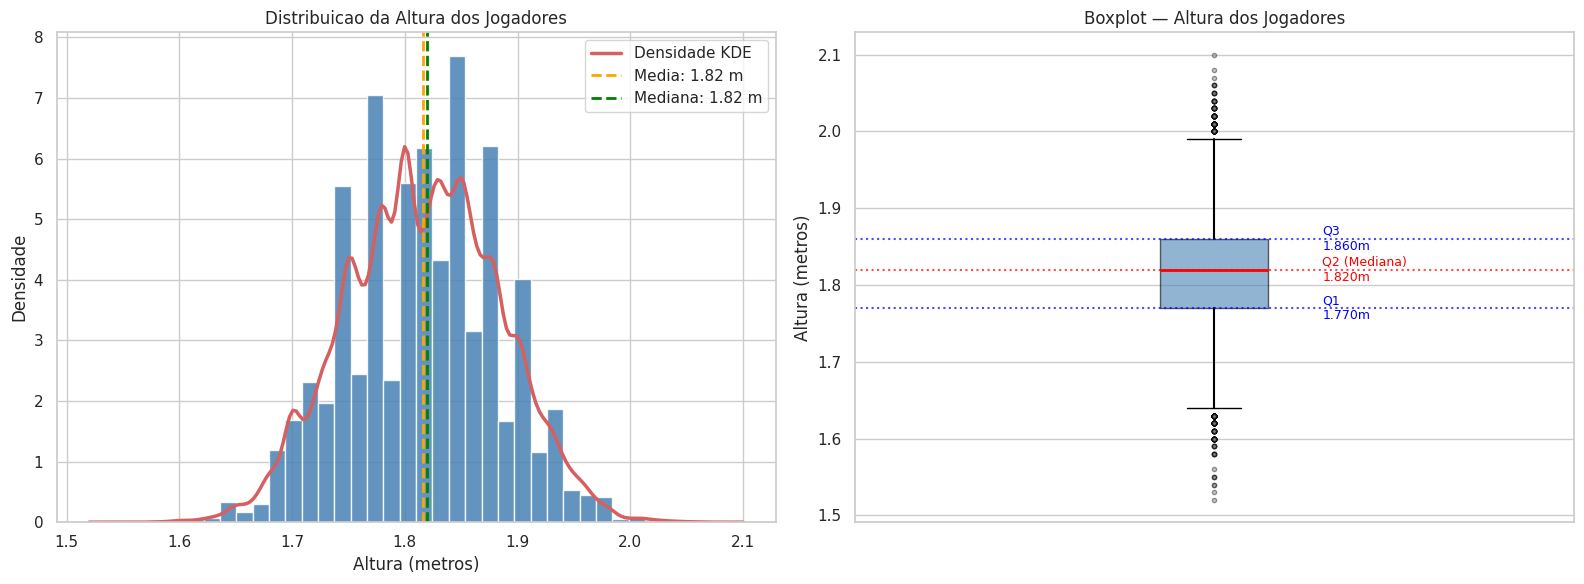

Como ler o Boxplot:
  Linha vermelha central = Mediana (1.820 m)
  Caixa azul = IQR: de Q1 (1.770) ate Q3 (1.860)
  Bigodes = limites sem outliers
  Pontos isolados = outliers


In [18]:
# ============================================================
# BLOCO 6A — Histograma + Boxplot lado a lado
# ============================================================

if len(df_altura) < 2:
    print("AVISO: df_altura sem dados suficientes. Verifique o Bloco 3A.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    ax1.hist(df_altura['altura_m'], bins=40, color='steelblue',
             edgecolor='white', alpha=0.85, density=True)

    xmin, xmax = df_altura['altura_m'].min(), df_altura['altura_m'].max()
    x = np.linspace(xmin, xmax, 200)
    kde = stats.gaussian_kde(df_altura['altura_m'].dropna())
    ax1.plot(x, kde(x), 'r-', linewidth=2.5, label='Densidade KDE')

    ax1.axvline(media, color='orange', linestyle='--', linewidth=2,
                label=f'Media: {media:.2f} m')
    ax1.axvline(mediana, color='green', linestyle='--', linewidth=2,
                label=f'Mediana: {mediana:.2f} m')

    ax1.set_xlabel('Altura (metros)')
    ax1.set_ylabel('Densidade')
    ax1.set_title('Distribuicao da Altura dos Jogadores')
    ax1.legend()

    ax2 = axes[1]
    ax2.boxplot(df_altura['altura_m'].dropna(),
                vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='gray',
                               markersize=3, alpha=0.4))

    ax2.set_ylabel('Altura (metros)')
    ax2.set_title('Boxplot — Altura dos Jogadores')
    ax2.set_xticks([])

    for val, label, color in [(q1,'Q1','blue'), (mediana,'Q2 (Mediana)','red'),
                               (q3,'Q3','blue')]:
        ax2.axhline(val, color=color, linestyle=':', alpha=0.7)
        ax2.text(1.15, val, f'{label}\n{val:.3f}m',
                 ha='left', va='center', fontsize=9, color=color)

    plt.tight_layout()
    plt.savefig('histograma_altura.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Como ler o Boxplot:")
    print(f"  Linha vermelha central = Mediana ({mediana:.3f} m)")
    print(f"  Caixa azul = IQR: de Q1 ({q1:.3f}) ate Q3 ({q3:.3f})")
    print(f"  Bigodes = limites sem outliers")
    print(f"  Pontos isolados = outliers")

### Bloco 6B — Boxplot por Posicao

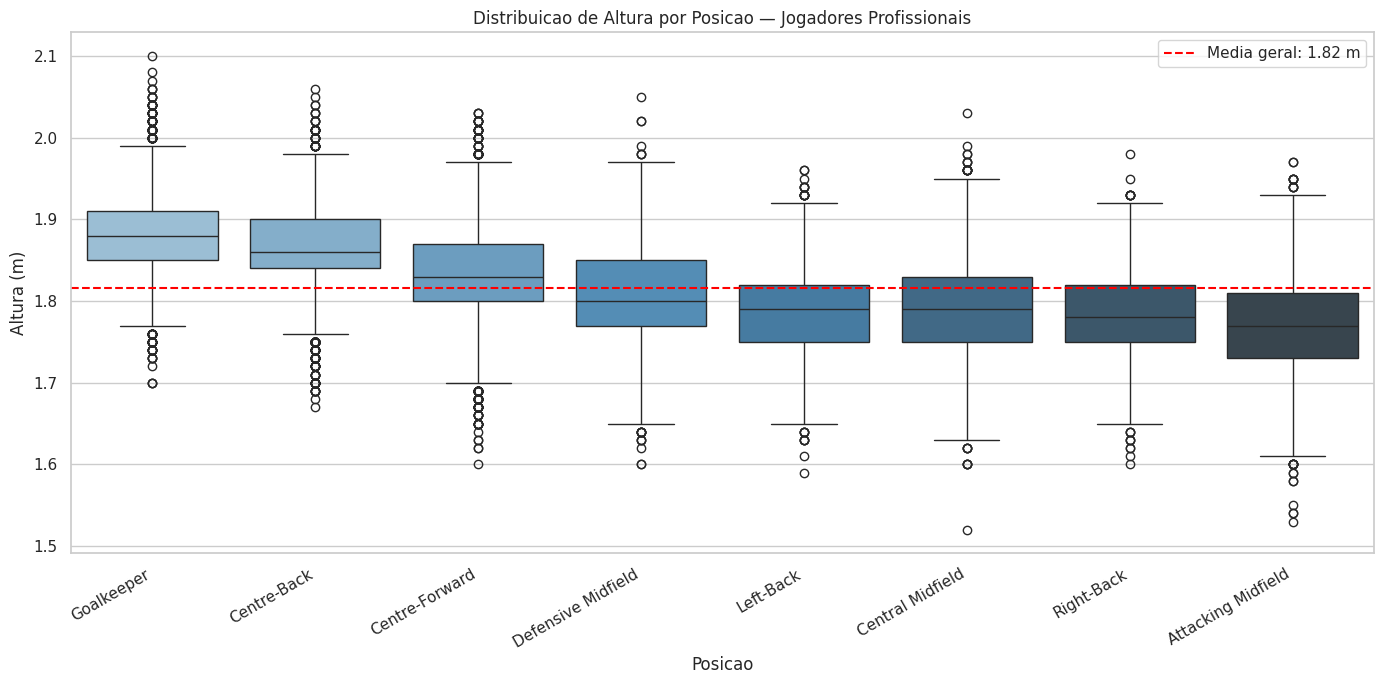

Goleiros e zagueiros tendem a ser mais altos.
Meias e pontas costumam ter menor estatura.


In [19]:
# ============================================================
# BLOCO 6B — Boxplot de altura agrupado por posicao
# ============================================================

# Selecionar as 8 posicoes mais frequentes para o grafico nao ficar poluido
top_posicoes = df_altura['Position'].value_counts().head(8).index.tolist()
df_pos = df_altura[df_altura['Position'].isin(top_posicoes)].copy()

# Criar coluna com nome abreviado da posicao
df_pos['posicao_curta'] = df_pos['Position'].str.split(' - ').str[-1]

# Ordenar as posicoes pela mediana de altura (decrescente) para facilitar leitura
ordem = (
    df_pos.groupby('posicao_curta')['altura_m']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 7))
# sns.boxplot cria um boxplot para cada categoria em 'x', agrupando automaticamente
# order= define a sequencia das categorias no eixo x
sns.boxplot(
    data=df_pos,
    x='posicao_curta',
    y='altura_m',
    order=ordem,
    palette='Blues_d'
)

# Linha horizontal indicando a media geral como referencia
plt.axhline(media, color='red', linestyle='--', linewidth=1.5,
            label=f'Media geral: {media:.2f} m')
plt.xlabel('Posicao')
plt.ylabel('Altura (m)')
plt.title('Distribuicao de Altura por Posicao — Jogadores Profissionais')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print("Goleiros e zagueiros tendem a ser mais altos.")
print("Meias e pontas costumam ter menor estatura.")

### Bloco 6C — Grafico de Barras Horizontais

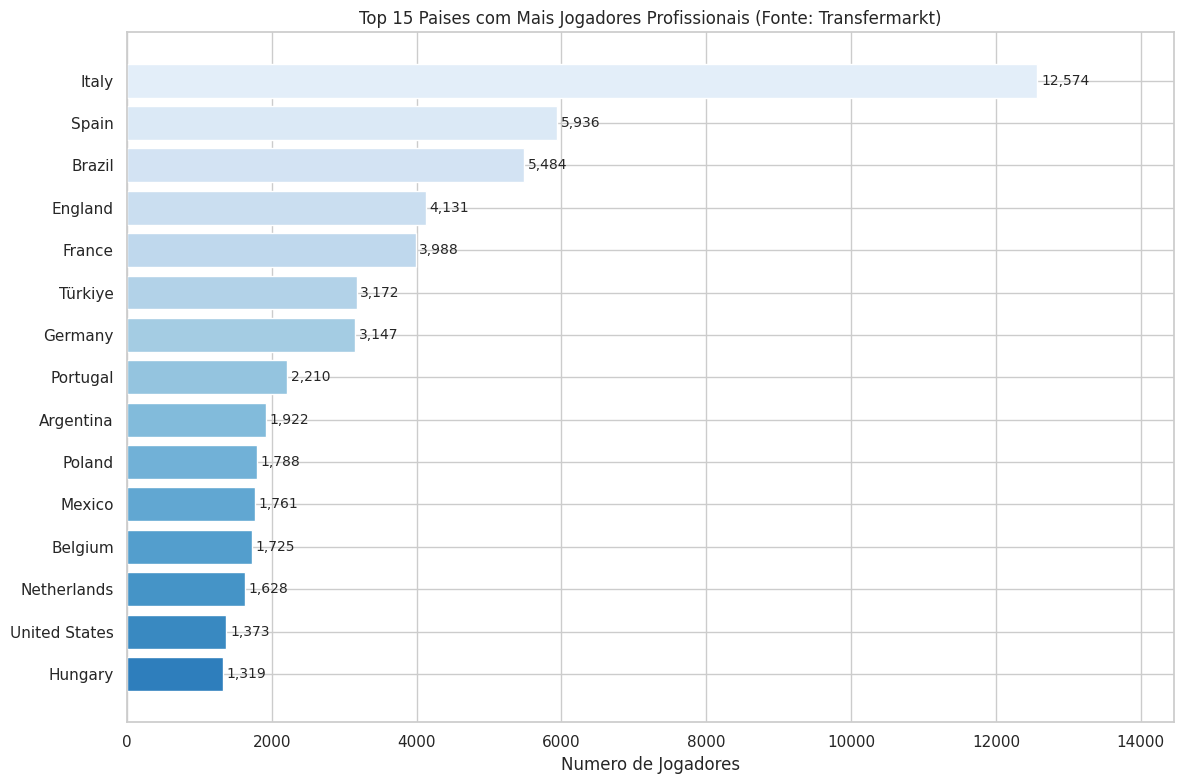

In [20]:
# ============================================================
# BLOCO 6C — Grafico de barras horizontais — Top 15 Paises
# ============================================================

top15_paises = df_perfis['Citizenship'].value_counts().head(15)

# plt.cm.Blues_r gera uma paleta de azuis do escuro para o claro
# np.linspace(0.3, 0.9, 15) cria 15 valores entre 0.3 e 0.9 para indexar a paleta
cores = plt.cm.Blues_r(np.linspace(0.3, 0.9, 15))

fig, ax = plt.subplots(figsize=(12, 8))

# [::-1] inverte a ordem para que o maior valor fique no topo do grafico
bars = ax.barh(top15_paises.index[::-1], top15_paises.values[::-1],
               color=cores, edgecolor='white')

# Adicionar o valor exato ao final de cada barra
for bar, val in zip(bars, top15_paises.values[::-1]):
    # bar.get_width() retorna o comprimento da barra (o valor da contagem)
    # bar.get_y() + bar.get_height()/2 calcula o centro vertical da barra
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=10)

ax.set_xlabel('Numero de Jogadores')
ax.set_title('Top 15 Paises com Mais Jogadores Profissionais (Fonte: Transfermarkt)')
ax.set_xlim(0, top15_paises.max() * 1.15)  # margem extra a direita para os rotulos

plt.tight_layout()
plt.show()

### Bloco 6D — Dispersao com Linha de Tendencia

In [21]:
# ============================================================
# BLOCO 6D -- Dispersao: Gols vs Assistencias
# ============================================================

# Diagnostico: mostrar colunas reais de df_perf
print('Colunas de df_perf:', df_perf.columns.tolist())

# Mapeamento de colunas: adapta nomes do CSV real para o esperado pelo codigo
MAPA_PERF = {
    'Goals': 'goals', 'goal': 'goals', 'goals_scored': 'goals',
    'Assists': 'assists', 'assist': 'assists', 'assists_total': 'assists',
    'Minutes': 'minutes_played', 'minutes': 'minutes_played',
    'Mins': 'minutes_played', 'min': 'minutes_played', 'mins': 'minutes_played',
    'Minutes played': 'minutes_played',
    'Yellow cards': 'yellow_cards', 'Yellow Cards': 'yellow_cards',
    'yellow_card': 'yellow_cards', 'YC': 'yellow_cards',
    'Red cards': 'direct_red_cards', 'Red Cards': 'direct_red_cards',
    'red_cards': 'direct_red_cards', 'RC': 'direct_red_cards',
    'red_card': 'direct_red_cards',
}

df_perf_work = df_perf.rename(columns={k: v for k, v in MAPA_PERF.items()
                                        if k in df_perf.columns})

COLS_NECESSARIAS = ['goals', 'assists', 'minutes_played']
COLS_OPCIONAIS   = ['yellow_cards', 'direct_red_cards']
faltando = [c for c in COLS_NECESSARIAS if c not in df_perf_work.columns]

if faltando:
    print(f'ERRO: colunas nao encontradas: {faltando}')
    print('Colunas disponiveis:', df_perf_work.columns.tolist())
else:
    cols_usar = [c for c in COLS_NECESSARIAS + COLS_OPCIONAIS
                 if c in df_perf_work.columns]
    df_perf_clean = df_perf_work[cols_usar].copy()

    for col in cols_usar:
        df_perf_clean[col] = pd.to_numeric(
            df_perf_clean[col].astype(str)
                .str.replace("'", '', regex=False)
                .str.replace('-', '0', regex=False),
            errors='coerce'
        )

    df_atacantes = df_perf_clean[
        (df_perf_clean['goals'] > 0) | (df_perf_clean['assists'] > 0)
    ].dropna(subset=['goals', 'assists'])

    amostra = df_atacantes.sample(min(3000, len(df_atacantes)), random_state=42)
    print(f'Amostra para scatter: {len(amostra)} registros')

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        amostra['goals'], amostra['assists'],
        alpha=0.4, s=20,
        c=amostra['goals'] + amostra['assists'],
        cmap='YlOrRd'
    )
    plt.colorbar(scatter, label='Gols + Assistencias')

    z = np.polyfit(amostra['goals'].dropna(), amostra['assists'].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, amostra['goals'].max(), 100)
    plt.plot(x_line, p(x_line), 'b--', linewidth=2, label='Linha de tendencia')

    plt.xlabel('Gols')
    plt.ylabel('Assistencias')
    plt.title('Relacao entre Gols e Assistencias por Temporada')
    plt.legend()
    plt.tight_layout()
    plt.show()

    corr = amostra['goals'].corr(amostra['assists'])
    print(f'Coeficiente de Correlacao de Pearson: r = {corr:.4f}')
    print(f'r = {corr:.2f} -> {"correlacao positiva moderada" if corr > 0.3 else "correlacao fraca"}') 


Colunas de df_perf: ['version https://git-lfs.github.com/spec/v1']
ERRO: colunas nao encontradas: ['goals', 'assists', 'minutes_played']
Colunas disponiveis: ['version https://git-lfs.github.com/spec/v1']


## Parte 7 — Analise de Correlacao

### Bloco 7A — Calculando a Matriz de Correlacao

In [22]:
# ============================================================
# BLOCO 7A -- Matriz de correlacao entre variaveis de desempenho
# ============================================================

variaveis_numericas = [c for c in ['goals', 'assists', 'yellow_cards',
                                    'direct_red_cards', 'minutes_played']
                       if c in df_perf_clean.columns]

print(f'Variaveis usadas na correlacao: {variaveis_numericas}')

df_num = df_perf_clean[variaveis_numericas].copy()

for col in variaveis_numericas:
    df_num[col] = pd.to_numeric(
        df_num[col].astype(str)
            .str.replace("'", '', regex=False)
            .str.replace('-', '0', regex=False)
            .str.strip(),
        errors='coerce'
    )

df_num = df_num.dropna()

matriz_corr = df_num.corr()

print('Matriz de Correlacao (Pearson):')
print(matriz_corr.round(3).to_string())


NameError: name 'df_perf_clean' is not defined

### Bloco 7B — Heatmap da Matriz de Correlacao

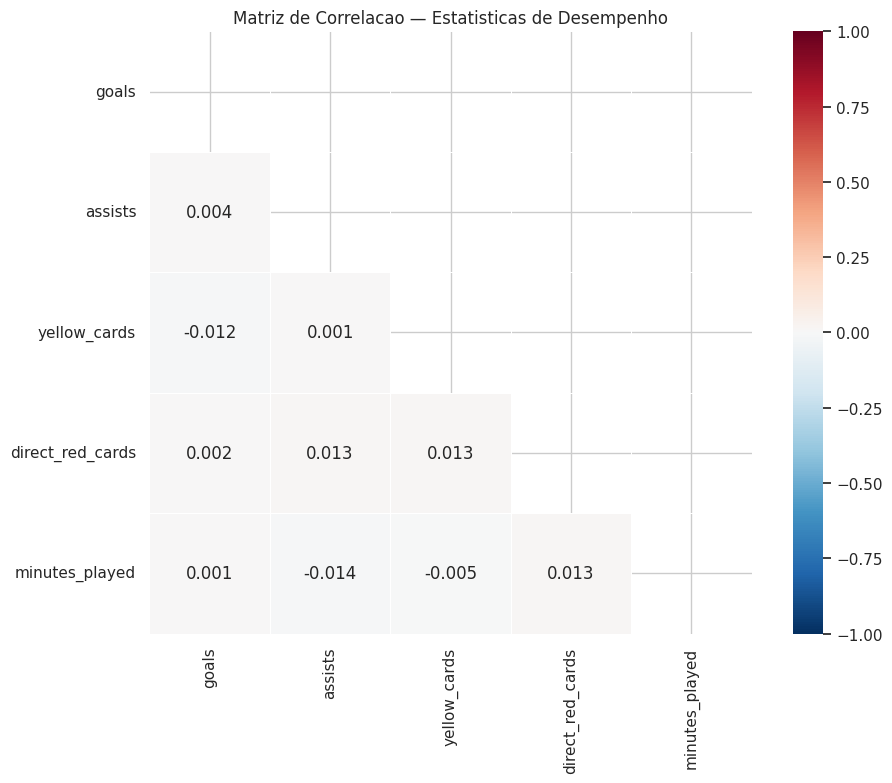


Como ler o heatmap:
  Celulas vermelhas   →  correlacao positiva (ambas sobem juntas)
  Celulas azuis       →  correlacao negativa (uma sobe, outra desce)
  Celulas brancas     →  sem correlacao linear

  Exemplo de interpretacao:
  Gols e minutos jogados tendem a ser correlacionados positivamente:
  quem joga mais tempo tem mais chances de marcar.



In [ ]:
# ============================================================
# BLOCO 7B — Heatmap da matriz de correlacao
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Criar mascara para ocultar o triangulo superior (evita duplicatas)
# np.triu retorna True nas posicoes da diagonal e acima dela
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr,
    mask=mask,            # triangulo superior sera ocultado
    annot=True,           # exibir o valor numerico dentro de cada celula
    fmt='.3f',            # formato com 3 casas decimais
    cmap='RdBu_r',        # vermelho (positivo) — branco (zero) — azul (negativo)
    center=0,             # centralizar a escala de cores no zero
    vmin=-1, vmax=1,      # limites fixos da escala
    ax=ax,
    square=True,          # celulas quadradas
    linewidths=0.5,       # linhas finas entre as celulas
    annot_kws={'size': 12}
)

ax.set_title('Matriz de Correlacao — Estatisticas de Desempenho')
plt.tight_layout()
plt.show()

print("""
Como ler o heatmap:
  Celulas vermelhas   →  correlacao positiva (ambas sobem juntas)
  Celulas azuis       →  correlacao negativa (uma sobe, outra desce)
  Celulas brancas     →  sem correlacao linear

  Exemplo de interpretacao:
  Gols e minutos jogados tendem a ser correlacionados positivamente:
  quem joga mais tempo tem mais chances de marcar.
""")

## Parte 8 — Dashboard Final

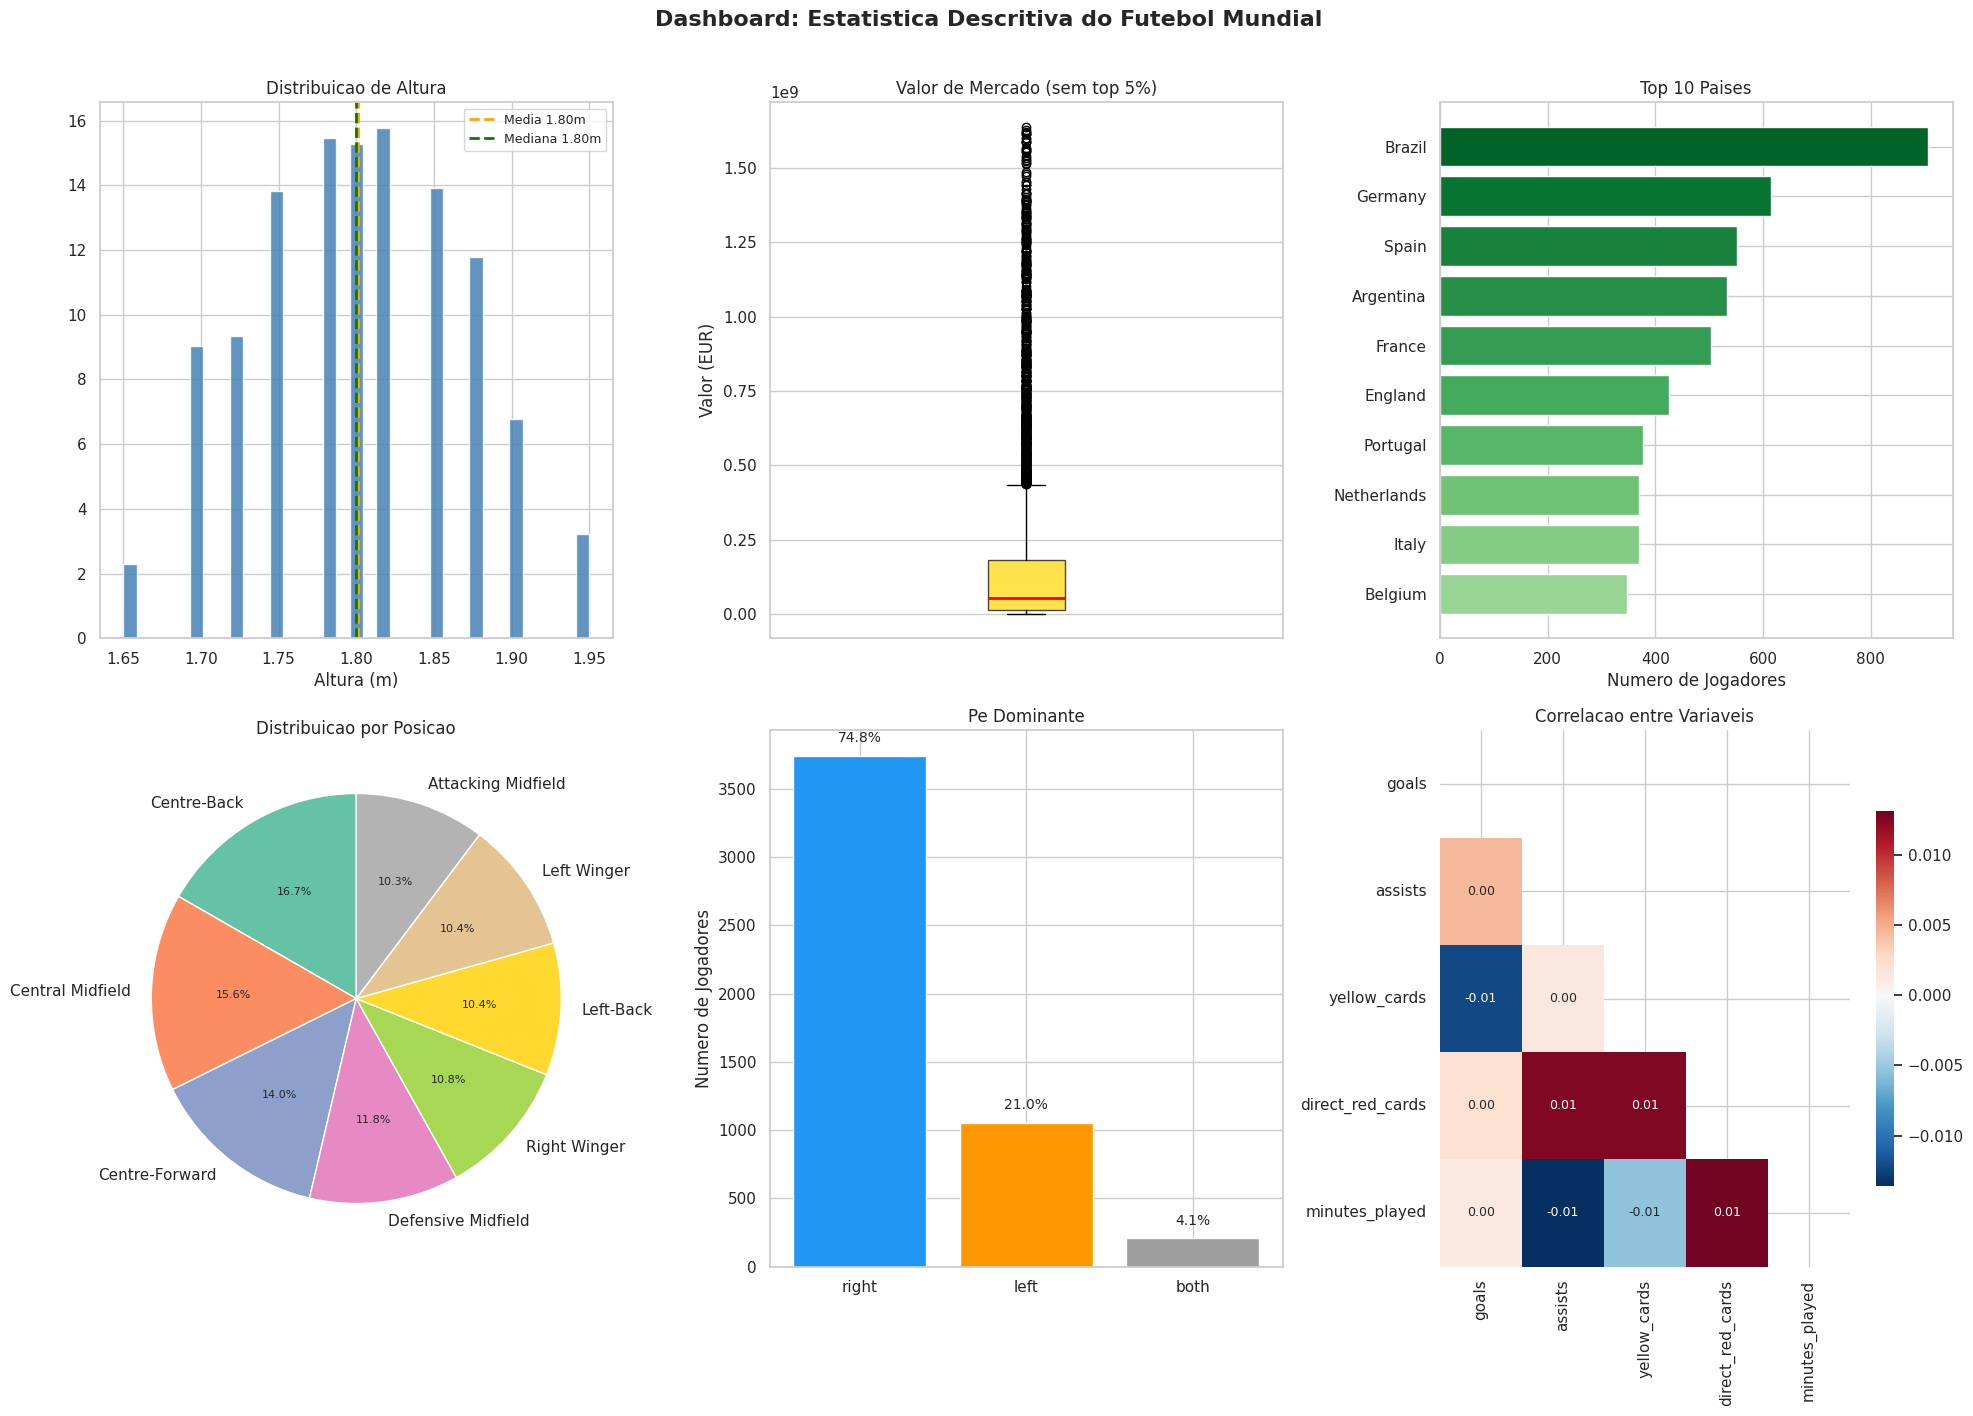

Dashboard salvo como 'dashboard_futebol.png'


In [ ]:
# ============================================================
# BLOCO 8 — Dashboard estatistico completo
# ============================================================

fig = plt.figure(figsize=(20, 14))
fig.suptitle('Dashboard: Estatistica Descritiva do Futebol Mundial',
             fontsize=16, fontweight='bold', y=1.01)

# Painel 1: Histograma de Altura
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(df_altura['altura_m'], bins=35, color='steelblue',
         edgecolor='white', alpha=0.85, density=True)
ax1.axvline(media, color='orange', linestyle='--', linewidth=2,
            label=f'Media {media:.2f}m')
ax1.axvline(mediana, color='green', linestyle='--', linewidth=2,
            label=f'Mediana {mediana:.2f}m')
ax1.set_title('Distribuicao de Altura')
ax1.set_xlabel('Altura (m)')
ax1.legend(fontsize=9)

# Painel 2: Boxplot de Valor de Mercado (sem os 5% mais altos para melhor visualizacao)
ax2 = fig.add_subplot(2, 3, 2)
valor_filtrado = valor[valor < valor.quantile(0.95)]
ax2.boxplot(valor_filtrado, vert=True, patch_artist=True,
            boxprops=dict(facecolor='gold', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_title('Valor de Mercado (sem top 5%)')
ax2.set_ylabel('Valor (EUR)')
ax2.set_xticks([])

# Painel 3: Top 10 Paises
ax3 = fig.add_subplot(2, 3, 3)
top10 = df_perfis['Citizenship'].value_counts().head(10)
ax3.barh(top10.index[::-1], top10.values[::-1],
         color=plt.cm.Greens(np.linspace(0.4, 0.9, 10)))
ax3.set_title('Top 10 Paises')
ax3.set_xlabel('Numero de Jogadores')

# Painel 4: Distribuicao de posicoes (pizza)
ax4 = fig.add_subplot(2, 3, 4)
top_pos = df_perfis['posicao_simples'].value_counts().head(8)
wedges, texts, autotexts = ax4.pie(
    top_pos.values,
    labels=top_pos.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2", 8),
    startangle=90
)
for text in autotexts:
    text.set_fontsize(8)
ax4.set_title('Distribuicao por Posicao')

# Painel 5: Pe dominante
ax5 = fig.add_subplot(2, 3, 5)
pe_counts = df_perfis['Foot'].value_counts()
cores_pe = ['#2196F3', '#FF9800', '#9E9E9E']
ax5.bar(pe_counts.index, pe_counts.values, color=cores_pe, edgecolor='white')
for i, (idx, val_pe) in enumerate(pe_counts.items()):
    pct = val_pe / len(df_perfis) * 100
    ax5.text(i, val_pe + 100, f'{pct:.1f}%', ha='center', fontsize=10)
ax5.set_title('Pe Dominante')
ax5.set_ylabel('Numero de Jogadores')

# Painel 6: Heatmap de correlacao
ax6 = fig.add_subplot(2, 3, 6)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax6,
            cbar_kws={'shrink': 0.7},
            annot_kws={'size': 9})
ax6.set_title('Correlacao entre Variaveis')

plt.tight_layout()
plt.savefig('dashboard_futebol.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dashboard salvo como 'dashboard_futebol.png'")

## Exercicios Praticos

### Exercicio 1 — Gabarito (Nivel Basico)

**Gabarito:**

In [ ]:
lesoes_por_jogador  = df_lesoes.groupby('player_id').size()

media_lesoes        = lesoes_por_jogador.mean()
mediana_lesoes      = lesoes_por_jogador.median()
jogadores_com_lesao = lesoes_por_jogador.count()

print(f"Media de lesoes por jogador : {media_lesoes:.2f}")
print(f"Mediana                     : {mediana_lesoes:.1f}")
print(f"Jogadores com lesao         : {jogadores_com_lesao:,}")

Media de lesoes por jogador : 1.60
Mediana                     : 1.0
Jogadores com lesao         : 3,125


### Exercicio 2 — Gabarito (Nivel Intermediario)

**Gabarito:**

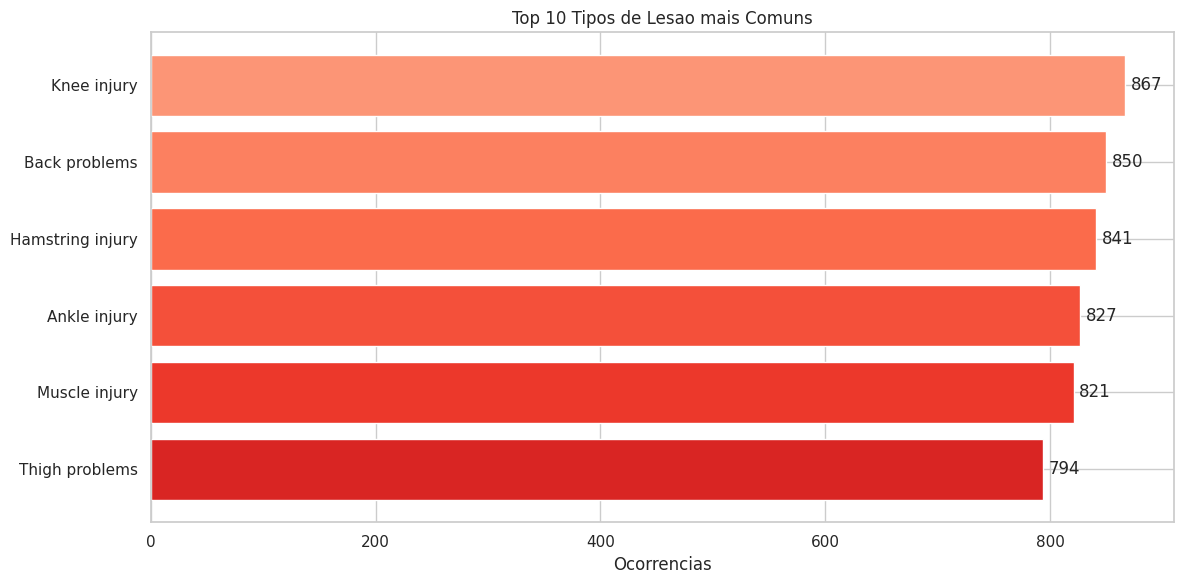

In [ ]:
top10_lesoes = df_lesoes['injury_reason'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))

cores = plt.cm.Reds_r(np.linspace(0.3, 0.9, 10))
bars = ax.barh(top10_lesoes.index[::-1], top10_lesoes.values[::-1], color=cores)

for bar, val in zip(bars, top10_lesoes.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left')

ax.set_title('Top 10 Tipos de Lesao mais Comuns')
ax.set_xlabel('Ocorrencias')
plt.tight_layout()
plt.show()

### Exercicio 3 — Gabarito (Nivel Avancado)

**Gabarito:**

                           mean      median  count
posicao_simples                                   
Central Midfield    349642312.0  69415000.0    631
Left Winger         517673352.0  68744500.0    420
Goalkeeper          437758139.0  67358000.0    303
Centre-Back         479530885.0  64579000.0    671
Left-Back           315182449.0  59437000.0    421
Right Winger        578562059.0  59217500.0    440
Centre-Forward      575221731.0  58162000.0    569
Right-Back          348353721.0  56111000.0    398
Attacking Midfield  373323540.0  54659000.0    415
Defensive Midfield  335153622.0  50247000.0    471


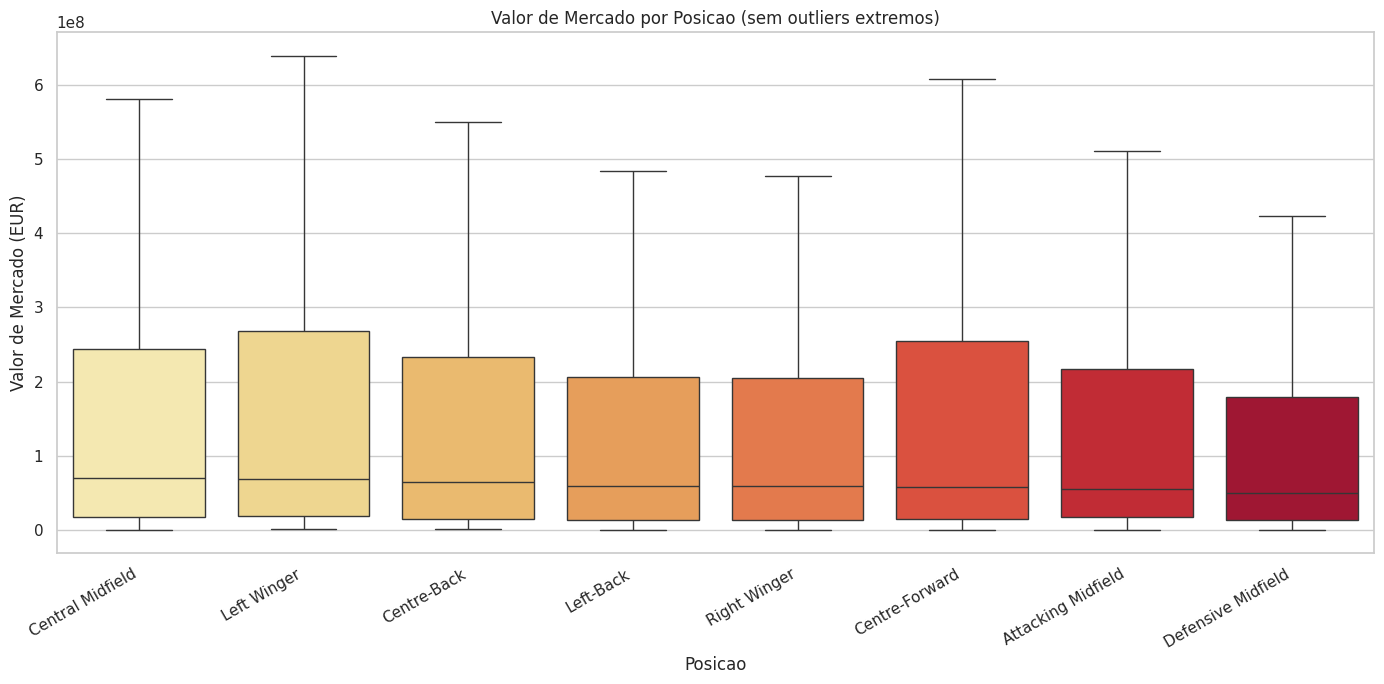

Posicao com maior valor mediano: Central Midfield
  Mediana: EUR 69,415,000


In [ ]:
# Passo 1: merge
df_merged = df_valor_recente.merge(
    df_perfis[['player_id', 'posicao_simples']],
    on='player_id',
    how='inner'
)

# Passo 2: agrupamento
resumo = (
    df_merged.groupby('posicao_simples')['value']
    .agg(['mean', 'median', 'count'])
    .sort_values('median', ascending=False)
)
print(resumo.round(0).to_string())

# Passo 3: boxplot
top_pos = df_merged['posicao_simples'].value_counts().head(8).index
df_plot = df_merged[df_merged['posicao_simples'].isin(top_pos)]
ordem = df_plot.groupby('posicao_simples')['value'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_plot, x='posicao_simples', y='value',
            order=ordem, palette='YlOrRd', showfliers=False)
plt.title('Valor de Mercado por Posicao (sem outliers extremos)')
plt.ylabel('Valor de Mercado (EUR)')
plt.xlabel('Posicao')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Passo 4: resultado
print(f"Posicao com maior valor mediano: {resumo.index[0]}")
print(f"  Mediana: EUR {resumo['median'].iloc[0]:,.0f}")

## Resumo da Aula — Cheat Sheet

In [ ]:
# ============================================================
# BLOCO FINAL — Cheat Sheet para consulta rapida
# ============================================================

cheat_sheet = """
+----------------------------------------------------------+
|     CHEAT SHEET — ESTATISTICA DESCRITIVA COM PANDAS      |
+----------------------------------------------------------+
|  EXPLORACAO                                              |
|  df.shape              → (linhas, colunas)               |
|  df.info()             → tipos e contagem de nulos       |
|  df.head(n)            → primeiras n linhas              |
|  df.describe()         → resumo estatistico completo     |
|  df.isnull().sum()     → contagem de NaN por coluna      |
+----------------------------------------------------------+
|  TENDENCIA CENTRAL                                       |
|  df['col'].mean()      → media aritmetica                |
|  df['col'].median()    → mediana                         |
|  df['col'].mode()[0]   → moda (primeiro valor)           |
+----------------------------------------------------------+
|  DISPERSAO                                               |
|  df['col'].std()       → desvio padrao                   |
|  df['col'].var()       → variancia                       |
|  df['col'].quantile(q) → quantil (ex: 0.25, 0.75)       |
|  df['col'].max() - df['col'].min() → amplitude           |
+----------------------------------------------------------+
|  FREQUENCIAS                                             |
|  df['col'].value_counts()            → freq. absoluta    |
|  df['col'].value_counts(normalize=True) → freq. relativa |
|  df.groupby('col').agg(...)          → por grupo         |
+----------------------------------------------------------+
|  CORRELACAO                                              |
|  df.corr()             → matriz de correlacao completa   |
|  df['a'].corr(df['b']) → correlacao entre duas colunas   |
+----------------------------------------------------------+
|  VISUALIZACOES                                           |
|  plt.hist(x)           → histograma                      |
|  plt.boxplot(x)        → boxplot simples                 |
|  plt.scatter(x, y)     → dispersao                       |
|  plt.barh(cat, val)    → barras horizontais              |
|  sns.boxplot(...)      → boxplot agrupado por categoria  |
|  sns.heatmap(corr)     → mapa de calor de correlacao     |
+----------------------------------------------------------+
"""
print(cheat_sheet)


+----------------------------------------------------------+
|     CHEAT SHEET — ESTATISTICA DESCRITIVA COM PANDAS      |
+----------------------------------------------------------+
|  EXPLORACAO                                              |
|  df.shape              → (linhas, colunas)               |
|  df.info()             → tipos e contagem de nulos       |
|  df.head(n)            → primeiras n linhas              |
|  df.describe()         → resumo estatistico completo     |
|  df.isnull().sum()     → contagem de NaN por coluna      |
+----------------------------------------------------------+
|  TENDENCIA CENTRAL                                       |
|  df['col'].mean()      → media aritmetica                |
|  df['col'].median()    → mediana                         |
|  df['col'].mode()[0]   → moda (primeiro valor)           |
+----------------------------------------------------------+
|  DISPERSAO                                               |
|  df['col'].std()     